# CarDD Data Analysis

#01. Imports

In [2]:
from pathlib import Path 
import json
import os

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image 
from collections import Counter


#02. Dataset Paths

In [3]:
WORKING_DIR = Path.cwd()

In [4]:
import zipfile

In [5]:
CARDD_ZIP = r"C:\Users\Xlosn\Downloads\CarDD_release.zip"

WORKING_DIR = Path.cwd()

def find_carddd_zips(root):
    found = []
    for pattern in ["*CarDD*.zip", "*cardd*.zip"]:
        try:
            found.extend(root.rglob(pattern))
        except Exception:
            pass
    return list(dict.fromkeys(found))

if CARDD_ZIP:
    ZIP_PATH = Path(CARDD_ZIP).expanduser().resolve()
else:
    candidates = find_carddd_zips(WORKING_DIR)
    if not candidates:
        candidates = find_carddd_zips(Path.home())
    ZIP_PATH = candidates[0].resolve() if candidates else None

print("Notebook directory:", WORKING_DIR)
print("CarDD ZIP:", ZIP_PATH)

if ZIP_PATH is None:
    print("\nCarDD ZIP file not found.")
    print(f"Please set the correct path in CARDD_ZIP and rerun the cell.")
else:
    print(f"Exists: {ZIP_PATH.exists()}")
    if ZIP_PATH.exists():
        print(f"Size: {ZIP_PATH.stat().st_size / (1024**3):.2f} GB")

Notebook directory: c:\Users\xlosn\qaddir-vehicle-damage-assessment\notebooks
CarDD ZIP: C:\Users\xlosn\Downloads\CarDD_release.zip
Exists: True
Size: 5.63 GB


## 3. Inspect ZIP Structure

In [6]:
if ZIP_PATH is None or not ZIP_PATH.exists():
    raise FileNotFoundError(
        "CarDD ZIP غير موجود. عدّل CARDD_ZIP في الخلية السابقة."
    )

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()

print(f"Total ZIP entries: {len(names):,}")

for name in names[:120]:
    print(name)

print("\n--- File extensions ---")

suffix_counts = Counter(
    Path(n).suffix.lower()
    for n in names
    if not n.endswith("/")
)

for suffix, count in suffix_counts.most_common():
    print(f"{suffix or '[none]':12s} {count:,}")

Total ZIP entries: 16,026
CarDD_release/
CarDD_release/CarDD_COCO/
CarDD_release/CarDD_COCO/annotations/
CarDD_release/CarDD_COCO/annotations/image_info.xlsx
CarDD_release/CarDD_COCO/annotations/instances_test2017.json
CarDD_release/CarDD_COCO/annotations/instances_train2017.json
CarDD_release/CarDD_COCO/annotations/instances_val2017.json
CarDD_release/CarDD_COCO/test2017/
CarDD_release/CarDD_COCO/test2017/000012.jpg
CarDD_release/CarDD_COCO/test2017/000015.jpg
CarDD_release/CarDD_COCO/test2017/000023.jpg
CarDD_release/CarDD_COCO/test2017/000033.jpg
CarDD_release/CarDD_COCO/test2017/000040.jpg
CarDD_release/CarDD_COCO/test2017/000042.jpg
CarDD_release/CarDD_COCO/test2017/000044.jpg
CarDD_release/CarDD_COCO/test2017/000057.jpg
CarDD_release/CarDD_COCO/test2017/000082.jpg
CarDD_release/CarDD_COCO/test2017/000088.jpg
CarDD_release/CarDD_COCO/test2017/000090.jpg
CarDD_release/CarDD_COCO/test2017/000106.jpg
CarDD_release/CarDD_COCO/test2017/000128.jpg
CarDD_release/CarDD_COCO/test2017/00015

In [7]:
json_files = [n for n in names if n.lower().endswith(".json")]
yaml_files = [n for n in names if n.lower().endswith((".yaml", ".yml"))]
image_files_in_zip = [
    n for n in names
    if Path(n).suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

print("JSON files:")
for x in json_files[:80]:
    print(" ", x)

print("\nYAML files:")
for x in yaml_files[:50]:
    print(" ", x)

print(f"\nImages in ZIP: {len(image_files_in_zip):,}")


JSON files:
  CarDD_release/CarDD_COCO/annotations/instances_test2017.json
  CarDD_release/CarDD_COCO/annotations/instances_train2017.json
  CarDD_release/CarDD_COCO/annotations/instances_val2017.json

YAML files:

Images in ZIP: 16,000


## 4. Extract Only Metadata / Annotation Files

In [8]:
EXTRACT_DIR = WORKING_DIR / "cardd_eda_extracted"
EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    extracted = []
    for name in json_files + yaml_files:
        p = Path(name)
        if ".." in p.parts or p.is_absolute():
            continue
        try:
            z.extract(name, EXTRACT_DIR)
            extracted.append(name)
        except Exception:
            pass

print(f"Extracted metadata/config files: {len(extracted)}")
for x in extracted:
    print(" ", x)


Extracted metadata/config files: 3
  CarDD_release/CarDD_COCO/annotations/instances_test2017.json
  CarDD_release/CarDD_COCO/annotations/instances_train2017.json
  CarDD_release/CarDD_COCO/annotations/instances_val2017.json


## 5. Detect COCO Annotation Files

In [9]:
annotation_candidates = []

for rel_name in json_files:
    p = EXTRACT_DIR / rel_name
    try:
        with open(p, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict):
            keys = set(data)
            score = sum(k in keys for k in ["images", "annotations", "categories"])
            if score >= 2:
                annotation_candidates.append((score, rel_name, data))
    except Exception:
        pass

annotation_candidates.sort(reverse=True, key=lambda x: x[0])

for score, name, data in annotation_candidates:
    print(
        f"score={score} | {name} | "
        f"images={len(data.get('images', [])):,} | "
        f"annotations={len(data.get('annotations', [])):,} | "
        f"categories={len(data.get('categories', [])):,}"
    )

if not annotation_candidates:
    raise RuntimeError(
        "COCO JSON. JSOON not found. Check the printed JSON names in the previous cell."
    )

COCO_FILES = [x[1] for x in annotation_candidates]


score=3 | CarDD_release/CarDD_COCO/annotations/instances_test2017.json | images=374 | annotations=785 | categories=6
score=3 | CarDD_release/CarDD_COCO/annotations/instances_train2017.json | images=2,816 | annotations=6,211 | categories=6
score=3 | CarDD_release/CarDD_COCO/annotations/instances_val2017.json | images=810 | annotations=1,744 | categories=6


## 6. Load Annotations

In [10]:
coco_datasets = {}

for rel_name in COCO_FILES:
    with open(EXTRACT_DIR / rel_name, "r", encoding="utf-8") as f:
        coco_datasets[rel_name] = json.load(f)

image_rows = []
annotation_rows = []
category_rows = []

for source_file, data in coco_datasets.items():
    cat_map = {
        c["id"]: c.get("name", str(c["id"]))
        for c in data.get("categories", [])
    }

    for c in data.get("categories", []):
        category_rows.append({
            "source_file": source_file,
            "category_id": c.get("id"),
            "category_name": c.get("name"),
            "supercategory": c.get("supercategory")
        })

    for img in data.get("images", []):
        row = dict(img)
        row["source_file"] = source_file
        image_rows.append(row)

    for ann in data.get("annotations", []):
        row = dict(ann)
        row["source_file"] = source_file
        row["category_name"] = cat_map.get(
            ann.get("category_id"),
            str(ann.get("category_id"))
        )
        annotation_rows.append(row)

images_df = pd.DataFrame(image_rows)
annotations_df = pd.DataFrame(annotation_rows)
categories_df = pd.DataFrame(category_rows)

print("images_df:", images_df.shape)
print("annotations_df:", annotations_df.shape)
print("categories_df:", categories_df.shape)

display(categories_df)


images_df: (4000, 6)
annotations_df: (8740, 10)
categories_df: (18, 4)


,source_file,category_id,category_name,supercategory
0,CarDD_release/CarDD_COCO/annotations/instances...,1,dent,None
1,CarDD_release/CarDD_COCO/annotations/instances...,2,scratch,None
2,CarDD_release/CarDD_COCO/annotations/instances...,3,crack,None
3,CarDD_release/CarDD_COCO/annotations/instances...,4,glass shatter,None
4,CarDD_release/CarDD_COCO/annotations/instances...,5,lamp broken,None
5,CarDD_release/CarDD_COCO/annotations/instances...,6,tire flat,None
6,CarDD_release/CarDD_COCO/annotations/instances...,1,dent,None
7,CarDD_release/CarDD_COCO/annotations/instances...,2,scratch,None
8,CarDD_release/CarDD_COCO/annotations/instances...,3,crack,None
9,CarDD_release/CarDD_COCO/annotations/instances...,4,glass shatter,None


## 7. Dataset Overview

In [11]:
print("=" * 60)
print("CarDD DATASET OVERVIEW")
print("=" * 60)

print(f"Total images:       {len(images_df):,}")
print(f"Total annotations:  {len(annotations_df):,}")
print(f"Total categories:   {len(categories_df):,}")

if "id" in images_df:
    print(f"Unique image IDs:   {images_df['id'].nunique():,}")

if "image_id" in annotations_df:
    print(f"Annotated images:   {annotations_df['image_id'].nunique():,}")

if {"width", "height"}.issubset(images_df.columns):
    print(f"Average width:      {images_df['width'].mean():,.1f}")
    print(f"Average height:     {images_df['height'].mean():,.1f}")
    print(f"Median width:       {images_df['width'].median():,.1f}")
    print(f"Median height:      {images_df['height'].median():,.1f}")


CarDD DATASET OVERVIEW
Total images:       4,000
Total annotations:  8,740
Total categories:   18
Unique image IDs:   4,000
Annotated images:   4,000
Average width:      978.1
Average height:     706.2
Median width:       1,000.0
Median height:      667.0


## 8. Class Distribution

In [12]:
pip install --upgrade --force-reinstall matplotlib

  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp311-cp311-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.__file__)

3.11.1
c:\Users\xlosn\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\__init__.py


,annotation_count
category_name,
scratch,3595
dent,2543
crack,898
lamp broken,704
glass shatter,681
tire flat,319


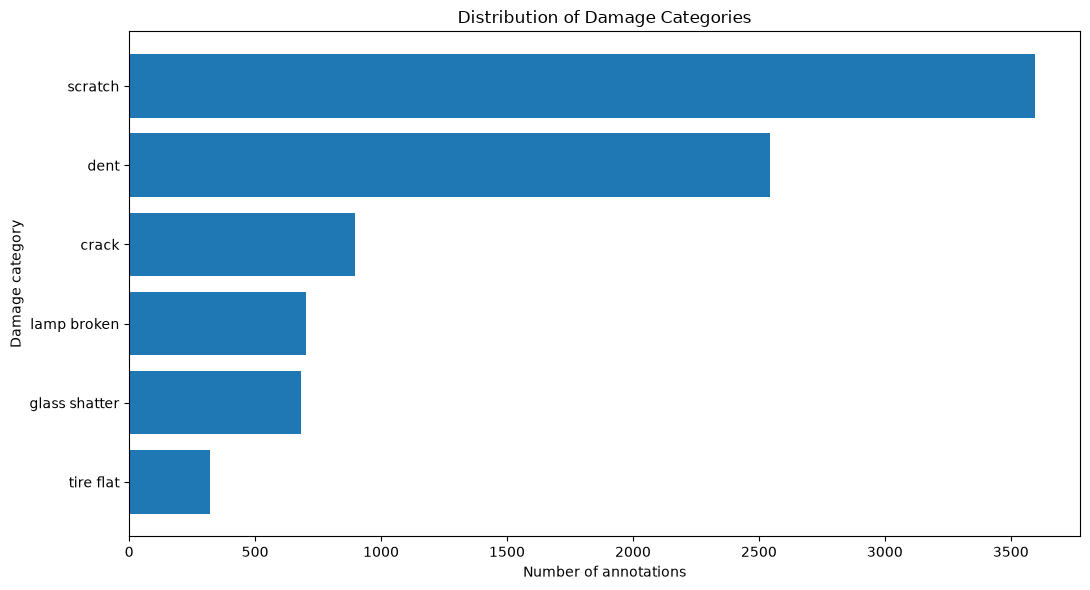

,percentage
category_name,
scratch,41.13
dent,29.10
crack,10.27
lamp broken,8.05
glass shatter,7.79
tire flat,3.65


In [14]:
if annotations_df.empty:
    print("No annotations found.")

else:
    class_counts = annotations_df["category_name"].value_counts()

    display(
        class_counts
        .rename("annotation_count")
        .to_frame()
    )

    # -----------------------------
    # Plot using Matplotlib directly
    # -----------------------------
    sorted_counts = class_counts.sort_values()

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.barh(
        sorted_counts.index.astype(str),
        sorted_counts.values
    )

    ax.set_title("Distribution of Damage Categories")
    ax.set_xlabel("Number of annotations")
    ax.set_ylabel("Damage category")

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Percentages
    # -----------------------------
    class_pct = (
        class_counts
        / class_counts.sum()
        * 100
    ).round(2)

    display(
        class_pct
        .rename("percentage")
        .to_frame()
    )

## 9. Unique Images per Damage Category

,unique_images
category_name,
scratch,2121
dent,1751
lamp broken,693
glass shatter,674
crack,604
tire flat,309


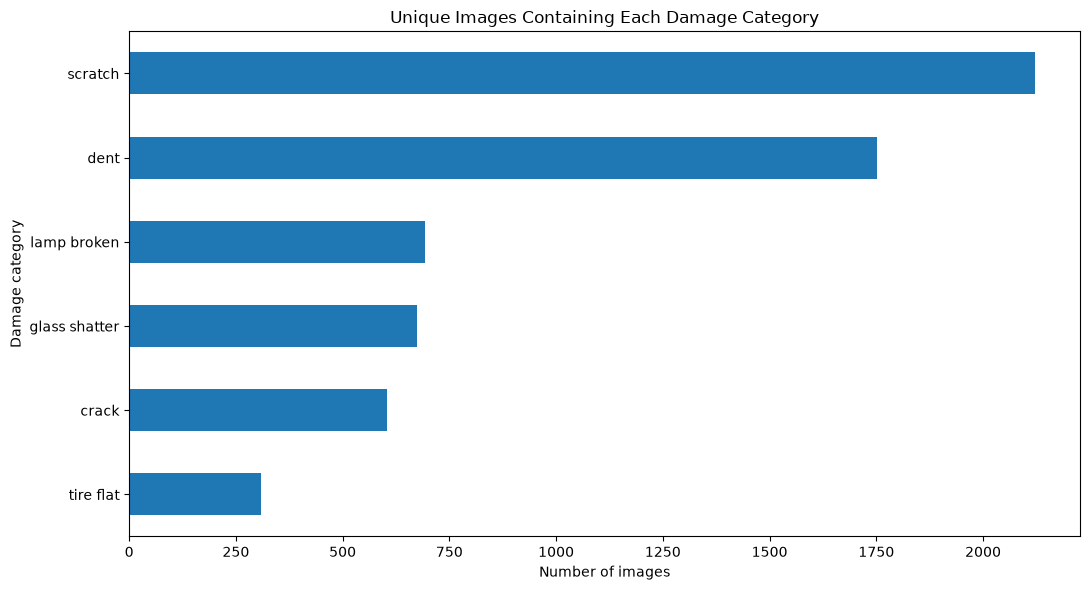

In [15]:
if not annotations_df.empty:
    images_per_class = (
        annotations_df.groupby("category_name")["image_id"]
        .nunique()
        .sort_values(ascending=False)
    )

    display(images_per_class.rename("unique_images").to_frame())

    plt.figure(figsize=(11, 6))
    images_per_class.sort_values().plot(kind="barh")
    plt.title("Unique Images Containing Each Damage Category")
    plt.xlabel("Number of images")
    plt.ylabel("Damage category")
    plt.tight_layout()
    plt.show()


## 10. Number of Damage Instances per Image

,objects_per_image
count,4000.000000
mean,2.185000
std,1.533415
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,13.000000


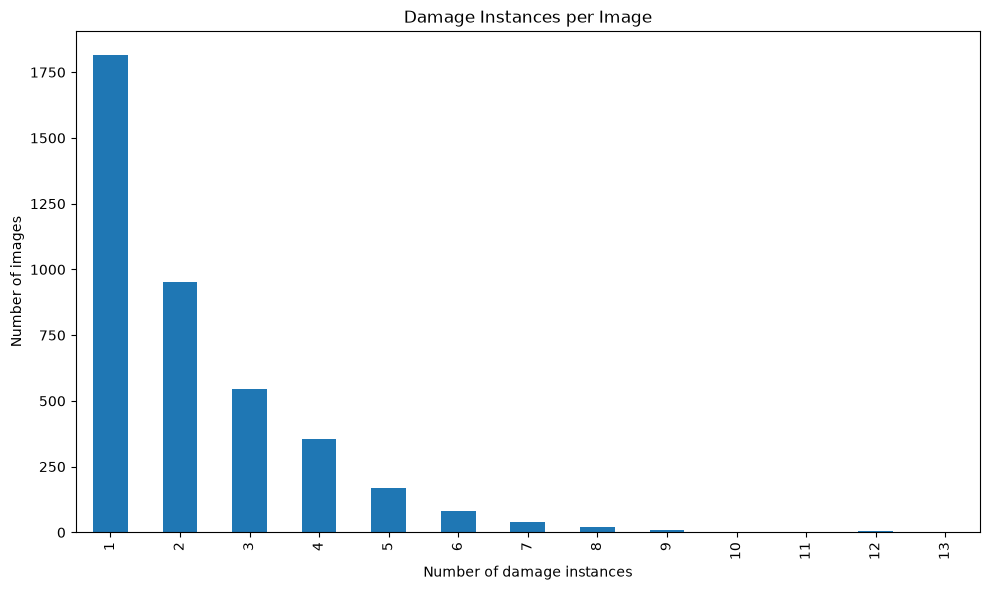

Images with 1 annotation:  1,816
Images with >1:           2,184
Maximum in one image:     13


In [16]:
if not annotations_df.empty:
    objects_per_image = annotations_df.groupby("image_id").size()

    display(objects_per_image.describe().to_frame("objects_per_image"))

    plt.figure(figsize=(10, 6))
    objects_per_image.value_counts().sort_index().plot(kind="bar")
    plt.title("Damage Instances per Image")
    plt.xlabel("Number of damage instances")
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.show()

    print(f"Images with 1 annotation:  {(objects_per_image == 1).sum():,}")
    print(f"Images with >1:           {(objects_per_image > 1).sum():,}")
    print(f"Maximum in one image:     {objects_per_image.max():,}")


## 11. Image Dimensions & Aspect Ratio

,width,height,aspect_ratio,image_area
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,978.058500,706.172750,1.416383,684231.250000
std,79.594095,97.850087,0.229340,54887.283836
min,562.000000,333.000000,0.562000,333000.000000
25%,1000.000000,667.000000,1.333333,667000.000000
50%,1000.000000,667.000000,1.499250,667000.000000
75%,1000.000000,750.000000,1.499250,674000.000000
max,1000.000000,1000.000000,3.003003,1000000.000000


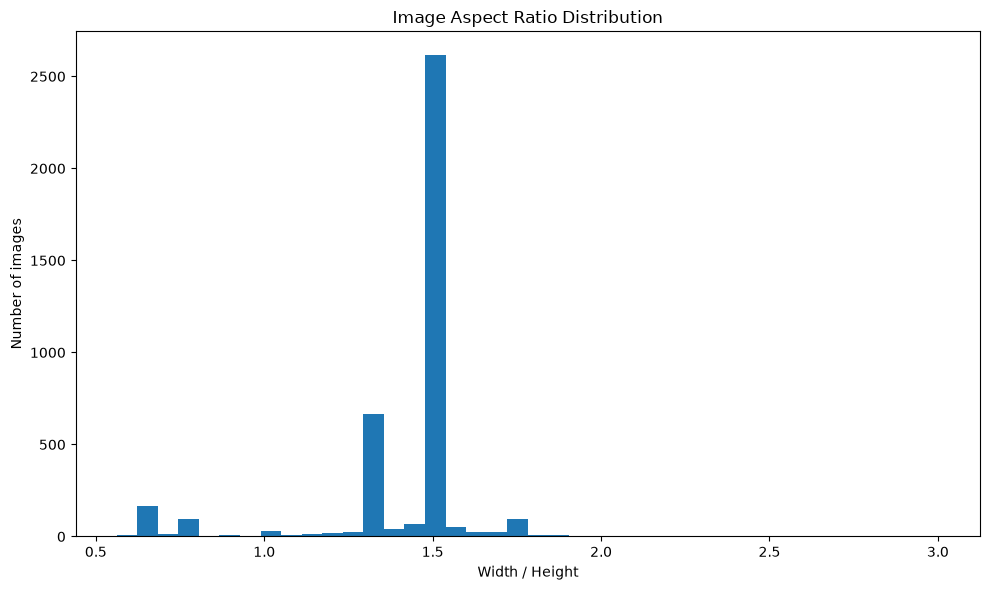

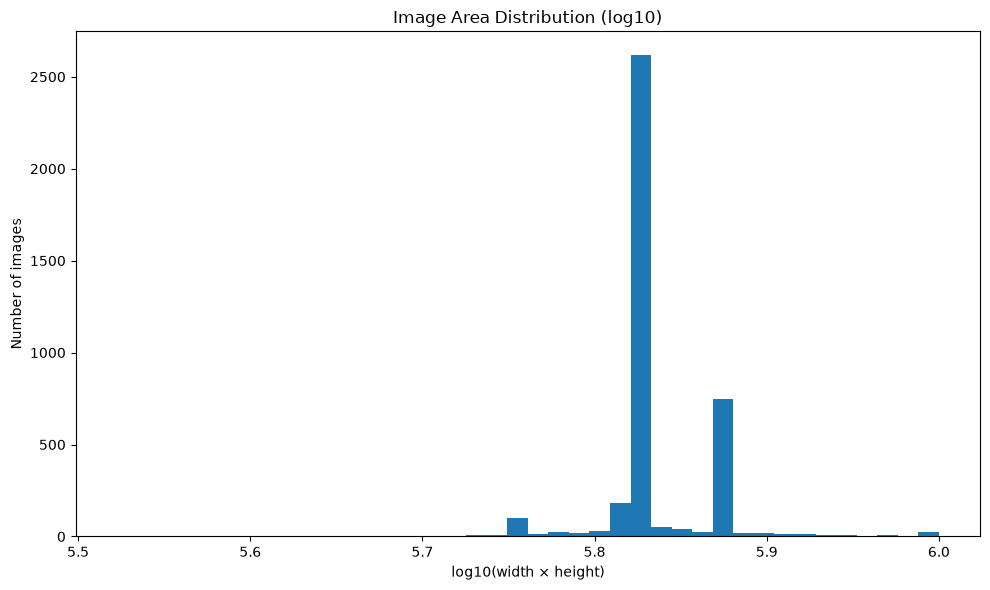

In [17]:
if {"width", "height"}.issubset(images_df.columns):
    images_df["aspect_ratio"] = images_df["width"] / images_df["height"]
    images_df["image_area"] = images_df["width"] * images_df["height"]

    display(
        images_df[["width", "height", "aspect_ratio", "image_area"]].describe()
    )

    plt.figure(figsize=(10, 6))
    plt.hist(images_df["aspect_ratio"].dropna(), bins=40)
    plt.title("Image Aspect Ratio Distribution")
    plt.xlabel("Width / Height")
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(np.log10(images_df["image_area"].dropna()), bins=40)
    plt.title("Image Area Distribution (log10)")
    plt.xlabel("log10(width × height)")
    plt.ylabel("Number of images")
    plt.tight_layout()
    plt.show()
else:
    print("Width/height information is not available.")


In [18]:
# Show JSON annotation files inside the ZIP

json_files = [
    name for name in names
    if name.lower().endswith(".json")
]

print(f"Number of JSON files: {len(json_files)}")

for name in json_files:
    print(name)

Number of JSON files: 3
CarDD_release/CarDD_COCO/annotations/instances_test2017.json
CarDD_release/CarDD_COCO/annotations/instances_train2017.json
CarDD_release/CarDD_COCO/annotations/instances_val2017.json


In [ ]:
json_paths = {
    "train": "CarDD_release/CarDD_COCO/annotations/instances_train2017.json",
    "val": "CarDD_release/CarDD_COCO/annotations/instances_val2017.json",
    "test": "CarDD_release/CarDD_COCO/annotations/instances_test2017.json"
}


annotations = {}

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    for split, path in json_paths.items():
        with z.open(path) as f:
            annotations[split] = json.load(f)

for split, data in annotations.items():
    print(f"{split.upper()}")
    print(f"Images: {len(data['images']):,}")
    print(f"Annotations: {len(data['annotations']):,}")
    print(f"Categories: {len(data['categories'])}")
    print()

TRAIN
Images: 2,816
Annotations: 6,211
Categories: 6

VAL
Images: 810
Annotations: 1,744
Categories: 6

TEST
Images: 374
Annotations: 785
Categories: 6



In [20]:
for split, data in annotations.items():
    print(f"\n--- {split.upper()} ---")
    
    for category in data["categories"]:
        print(
            f"ID: {category['id']} | "
            f"Name: {category['name']}"
        )


--- TRAIN ---
ID: 1 | Name: dent
ID: 2 | Name: scratch
ID: 3 | Name: crack
ID: 4 | Name: glass shatter
ID: 5 | Name: lamp broken
ID: 6 | Name: tire flat

--- VAL ---
ID: 1 | Name: dent
ID: 2 | Name: scratch
ID: 3 | Name: crack
ID: 4 | Name: glass shatter
ID: 5 | Name: lamp broken
ID: 6 | Name: tire flat

--- TEST ---
ID: 1 | Name: dent
ID: 2 | Name: scratch
ID: 3 | Name: crack
ID: 4 | Name: glass shatter
ID: 5 | Name: lamp broken
ID: 6 | Name: tire flat


In [ ]:
import pandas as pd

bbox_records = []

for split, data in annotations.items():

    
    image_info = {
        img["id"]: {
            "width": img["width"],
            "height": img["height"]
        }
        for img in data["images"]
    }

    category_info = {
        cat["id"]: cat["name"]
        for cat in data["categories"]
    }

    for ann in data["annotations"]:

        x, y, w, h = ann["bbox"]

        img = image_info[ann["image_id"]]

        image_width = img["width"]
        image_height = img["height"]

        bbox_area = w * h
        image_area = image_width * image_height

        bbox_records.append({
            "split": split,
            "image_id": ann["image_id"],
            "category": category_info[ann["category_id"]],
            "bbox_width": w,
            "bbox_height": h,
            "bbox_area": bbox_area,
            "image_width": image_width,
            "image_height": image_height,
            "bbox_area_ratio": bbox_area / image_area
        })

bbox_df = pd.DataFrame(bbox_records)

bbox_df.head()

,split,image_id,category,bbox_width,bbox_height,bbox_area,image_width,image_height,bbox_area_ratio
0,train,1,scratch,202.79,131.34,26634.4386,1000,750,0.035513
1,train,1,tire flat,684.19,551.02,377002.3738,1000,750,0.502670
2,train,2,tire flat,397.20,346.68,137701.2960,1000,667,0.206449
3,train,3,tire flat,645.71,521.12,336492.3952,1000,667,0.504486
4,train,4,tire flat,718.62,649.69,466880.2278,1000,667,0.699970


In [26]:
bbox_df[
    [
        "bbox_width",
        "bbox_height",
        "bbox_area",
        "bbox_area_ratio"
    ]
].describe()

,bbox_width,bbox_height,bbox_area,bbox_area_ratio
count,8740.000000,8740.000000,8740.000000,8740.000000
mean,343.031375,251.967538,117396.778473,0.171965
std,251.604636,178.640909,150838.883730,0.220753
min,7.510000,7.350000,116.616600,0.000175
25%,145.160000,108.830000,16818.641700,0.024646
50%,277.750000,205.425000,54233.657600,0.079700
75%,482.952500,357.762500,155707.979175,0.224889
max,1000.000000,1000.000000,886000.000000,1.000000


In [27]:
bbox_df.groupby("category")[
    [
        "bbox_width",
        "bbox_height",
        "bbox_area",
        "bbox_area_ratio"
    ]
].median().sort_values(
    "bbox_area_ratio"
)

,bbox_width,bbox_height,bbox_area,bbox_area_ratio
category,,,,
crack,87.235,83.950,6761.79515,0.010083
scratch,247.420,166.180,38556.95760,0.056416
dent,256.040,219.500,55312.70430,0.081746
lamp broken,435.340,271.345,122103.20350,0.181195
tire flat,477.610,491.430,234244.99980,0.347084
glass shatter,887.820,536.770,456543.77760,0.677810


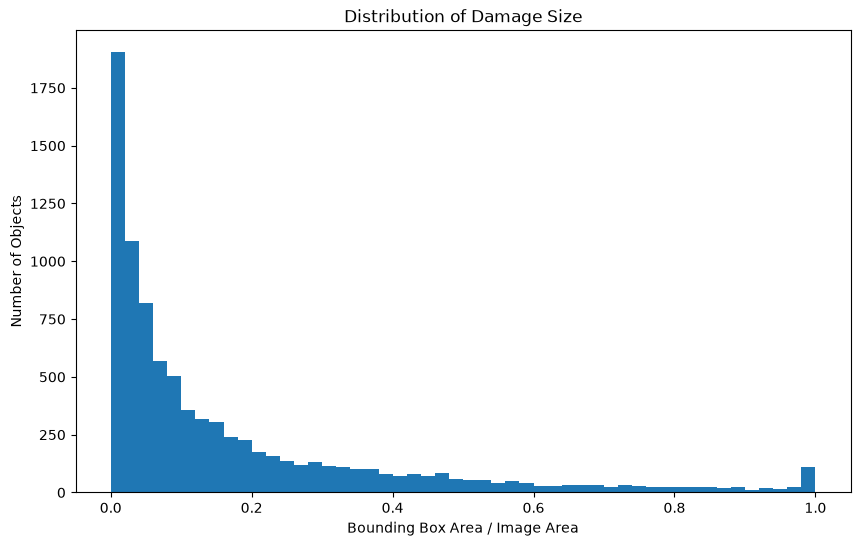

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    bbox_df["bbox_area_ratio"],
    bins=50
)

plt.xlabel("Bounding Box Area / Image Area")
plt.ylabel("Number of Objects")
plt.title("Distribution of Damage Size")

plt.show()

In [29]:
class_counts = (
    bbox_df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

print(class_counts)

category
scratch          3595
dent             2543
crack             898
lamp broken       704
glass shatter     681
tire flat         319
Name: count, dtype: int64


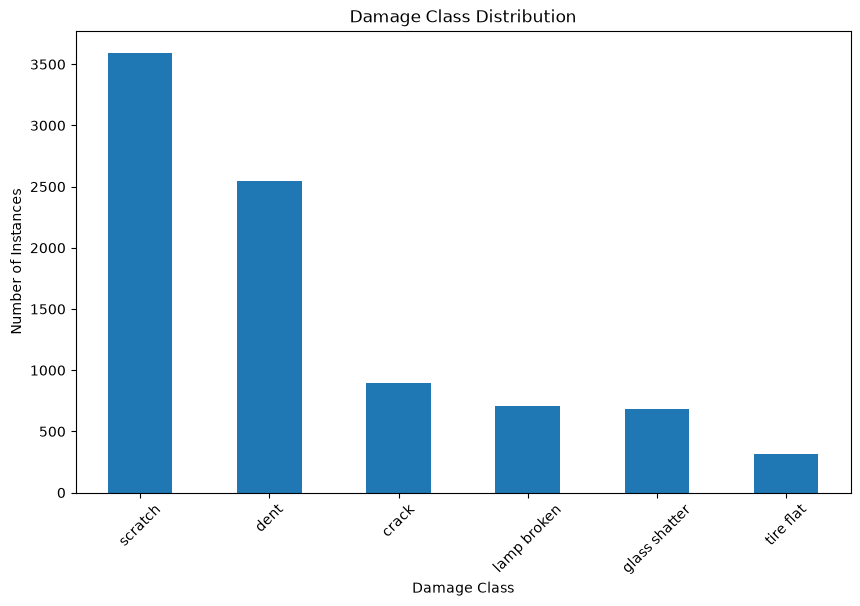

In [30]:
class_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Damage Class")
plt.ylabel("Number of Instances")
plt.title("Damage Class Distribution")

plt.xticks(rotation=45)
plt.show()

In [31]:
objects_per_image = (
    bbox_df
    .groupby(["split", "image_id"])
    .size()
    .reset_index(name="num_objects")
)

objects_per_image["num_objects"].describe()

count    4000.000000
mean        2.185000
std         1.533415
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        13.000000
Name: num_objects, dtype: float64

In [32]:
objects_per_image["num_objects"].value_counts().sort_index()

num_objects
1     1816
2      953
3      546
4      356
5      170
6       82
7       41
8       19
9        8
10       2
11       2
12       4
13       1
Name: count, dtype: int64